<a href="https://colab.research.google.com/github/ruhaan-reza/Machine-Learning/blob/Main/DiabetesModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [83]:
url = "https://raw.githubusercontent.com/ruhaan-reza/Machine-Learning/Main/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [85]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [88]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

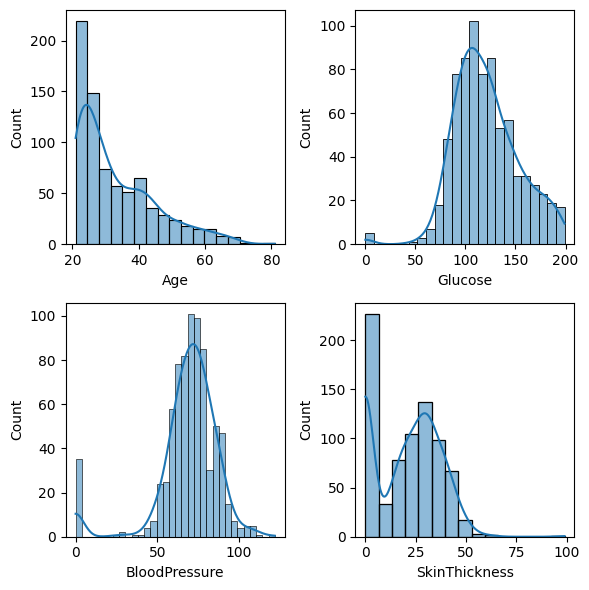

In [106]:

def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plt.figure(figsize=(6,6))
plotting('Age',1)
plotting('Glucose',2)
plotting('BloodPressure',3)
plotting('SkinThickness',4)

plt.tight_layout()

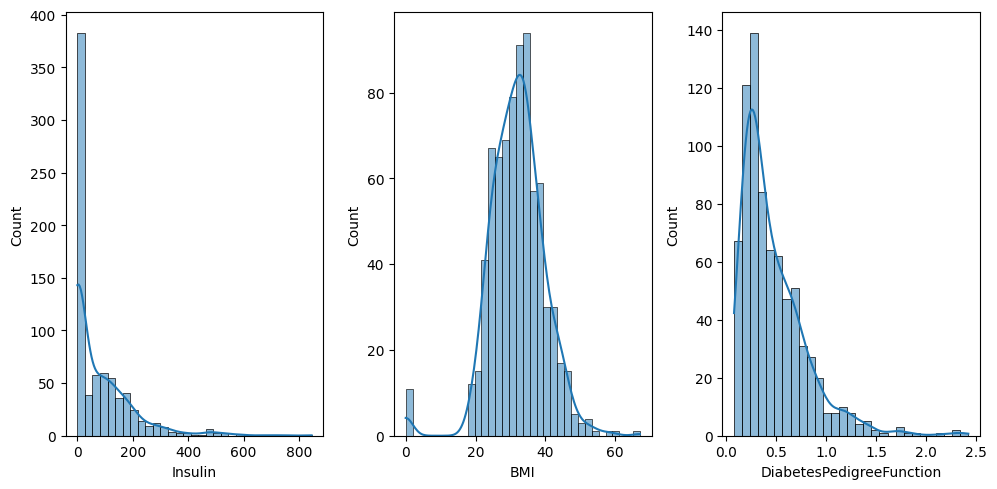

In [108]:
def plotting(var,num):
  plt.subplot(1,3,num)
  sns.histplot(df[var],kde=True)
plt.figure(figsize=(10,5))
plotting('Insulin',1)
plotting('BMI',2)
plotting('DiabetesPedigreeFunction',3)
plt.tight_layout()

<Axes: >

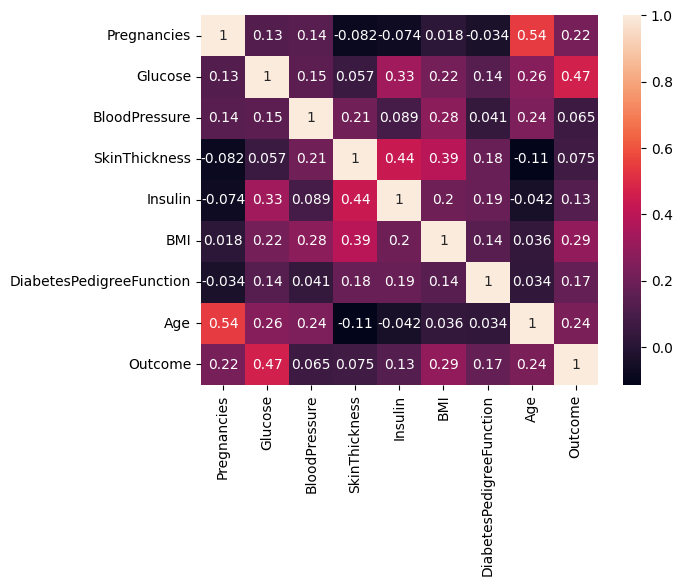

In [111]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [90]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [91]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [92]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [93]:
train_df = X_train.copy()
train_df['Outcome'] = y_train

In [94]:
glucose_med = train_df.loc[train_df['Glucose'] != 0, 'Glucose'].median()
bp_med      = train_df.loc[train_df['BloodPressure'] != 0, 'BloodPressure'].median()
skin_med    = train_df.loc[(train_df['SkinThickness'] > 0) & (train_df['SkinThickness'] <= 60), 'SkinThickness'].median()
bmi_med     = train_df.loc[train_df['BMI'] >= 18.2, 'BMI'].median()

In [96]:
insulin_med_0 = train_df.loc[(train_df['Outcome'] == 0) & (train_df['Insulin'] != 0), 'Insulin'].median()
insulin_med_1 = train_df.loc[(train_df['Outcome'] == 1) & (train_df['Insulin'] != 0), 'Insulin'].median()

In [97]:
X_train['Glucose']       = X_train['Glucose'].replace(0, glucose_med)
X_train['BloodPressure'] = X_train['BloodPressure'].replace(0, bp_med)
X_train.loc[(X_train['SkinThickness'] == 0) | (X_train['SkinThickness'] > 60), 'SkinThickness'] = skin_med
X_train.loc[X_train['BMI'] < 18.2, 'BMI'] = bmi_med

X_train.loc[(X_train['Insulin'] == 0) & (y_train == 0), 'Insulin'] = insulin_med_0
X_train.loc[(X_train['Insulin'] == 0) & (y_train == 1), 'Insulin'] = insulin_med_1

In [98]:
X_train.loc[(X_train['Insulin'] == 0) & (y_train == 0), 'Insulin'] = insulin_med_0
X_train.loc[(X_train['Insulin'] == 0) & (y_train == 1), 'Insulin'] = insulin_med_1

In [99]:
X_test['Glucose']       = X_test['Glucose'].replace(0, glucose_med)
X_test['BloodPressure'] = X_test['BloodPressure'].replace(0, bp_med)
X_test.loc[(X_test['SkinThickness'] == 0) | (X_test['SkinThickness'] > 60), 'SkinThickness'] = skin_med
X_test.loc[X_test['BMI'] < 18.2, 'BMI'] = bmi_med

In [100]:
X_test.loc[(X_test['Insulin'] == 0) & (y_test == 0), 'Insulin'] = insulin_med_0
X_test.loc[(X_test['Insulin'] == 0) & (y_test == 1), 'Insulin'] = insulin_med_1

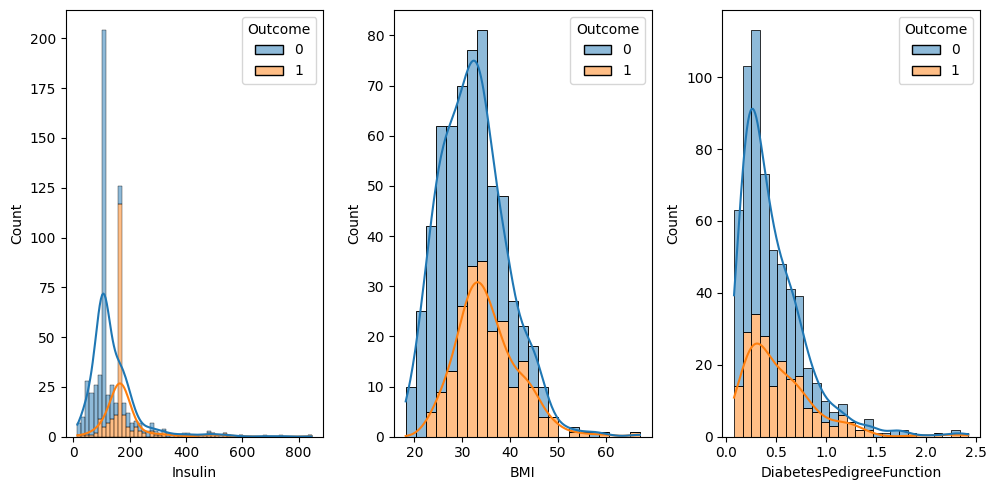

In [112]:
def plotting_updated(var, num):
    plt.subplot(1, 3, num)
    sns.histplot(data=X_train, x=var, hue=y_train, kde=True, multiple='stack')
plt.figure(figsize=(10, 5))
plotting_updated('Insulin', 1)
plotting_updated('BMI', 2)
plotting_updated('DiabetesPedigreeFunction', 3)
plt.tight_layout()
plt.show()

In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
result = []

In [104]:
for name in models:
    model = models[name]
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1
    })

In [105]:
result

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7662337662337663,
  'F1 Score': 0.6727272727272727},
 {'Model': 'Naive Bayes',
  'Accuracy': 0.7662337662337663,
  'F1 Score': 0.6785714285714286},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8636363636363636,
  'F1 Score': 0.8073394495412844},
 {'Model': 'SVM',
  'Accuracy': 0.8571428571428571,
  'F1 Score': 0.7962962962962963},
 {'Model': 'K-Nearest Neighbors',
  'Accuracy': 0.8051948051948052,
  'F1 Score': 0.7413793103448276}]

In [113]:
import joblib
joblib.dump(models['Decision Tree'],'DT_diabetes.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']